In [ ]:
#!/usr/bin/env python3.12.7
# -*- coding: utf-8 -*-


## Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
msw_wf_comp = pd.read_csv('../data/processed/msw_wf_composition_v4.csv')


In [4]:
msw_wf_comp_percent = pd.read_csv('../data/processed/msw_wf_composition_percent.csv')
el_comp_1 = pd.read_csv('../data/processed/elemental_data_from_lit.csv')
el_comp_2 = pd.read_csv('../data/processed/elemental_data_gotze.csv')
msw_data = pd.read_csv('../data/results/ALL_Scenarios.csv')
msw_sample = pd.read_csv('../data/external/country_sample.csv')

In [7]:
msw_wf_comp['Aggregated category name'].unique()

array(['mixed waste', 'chemical and medical', 'glass', 'paper', 'plastic',
       'wood', 'weee + batt + vehicles', 'organic waste',
       'common sludges', 'mineral waste', 'metal', 'textile + rubber'],
      dtype=object)

# Plots

## Totals

### Plot 1: Eurostat wasgen totals vs MSW totals

In [48]:
msw_wf_comp_total = msw_wf_comp.groupby(['unit','NUTS_code','Geopolitical entity (reporting)','TIME_PERIOD'])['OBS_VALUE'].sum().reset_index(name='MSW Total')

In [65]:
msw_wf_comp_total_exmin = msw_wf_comp.loc[~(msw_wf_comp['category code'].isin(['W12-13','W077_08', 'W01-05','W11']))].groupby(['unit','NUTS_code','Geopolitical entity (reporting)','TIME_PERIOD'])['OBS_VALUE'].sum().reset_index(name='MSW Total')

In [44]:
msw_data_total_plot  = msw_data.loc[msw_data['Scenario'].isin(['OBS', 'BAU'])]

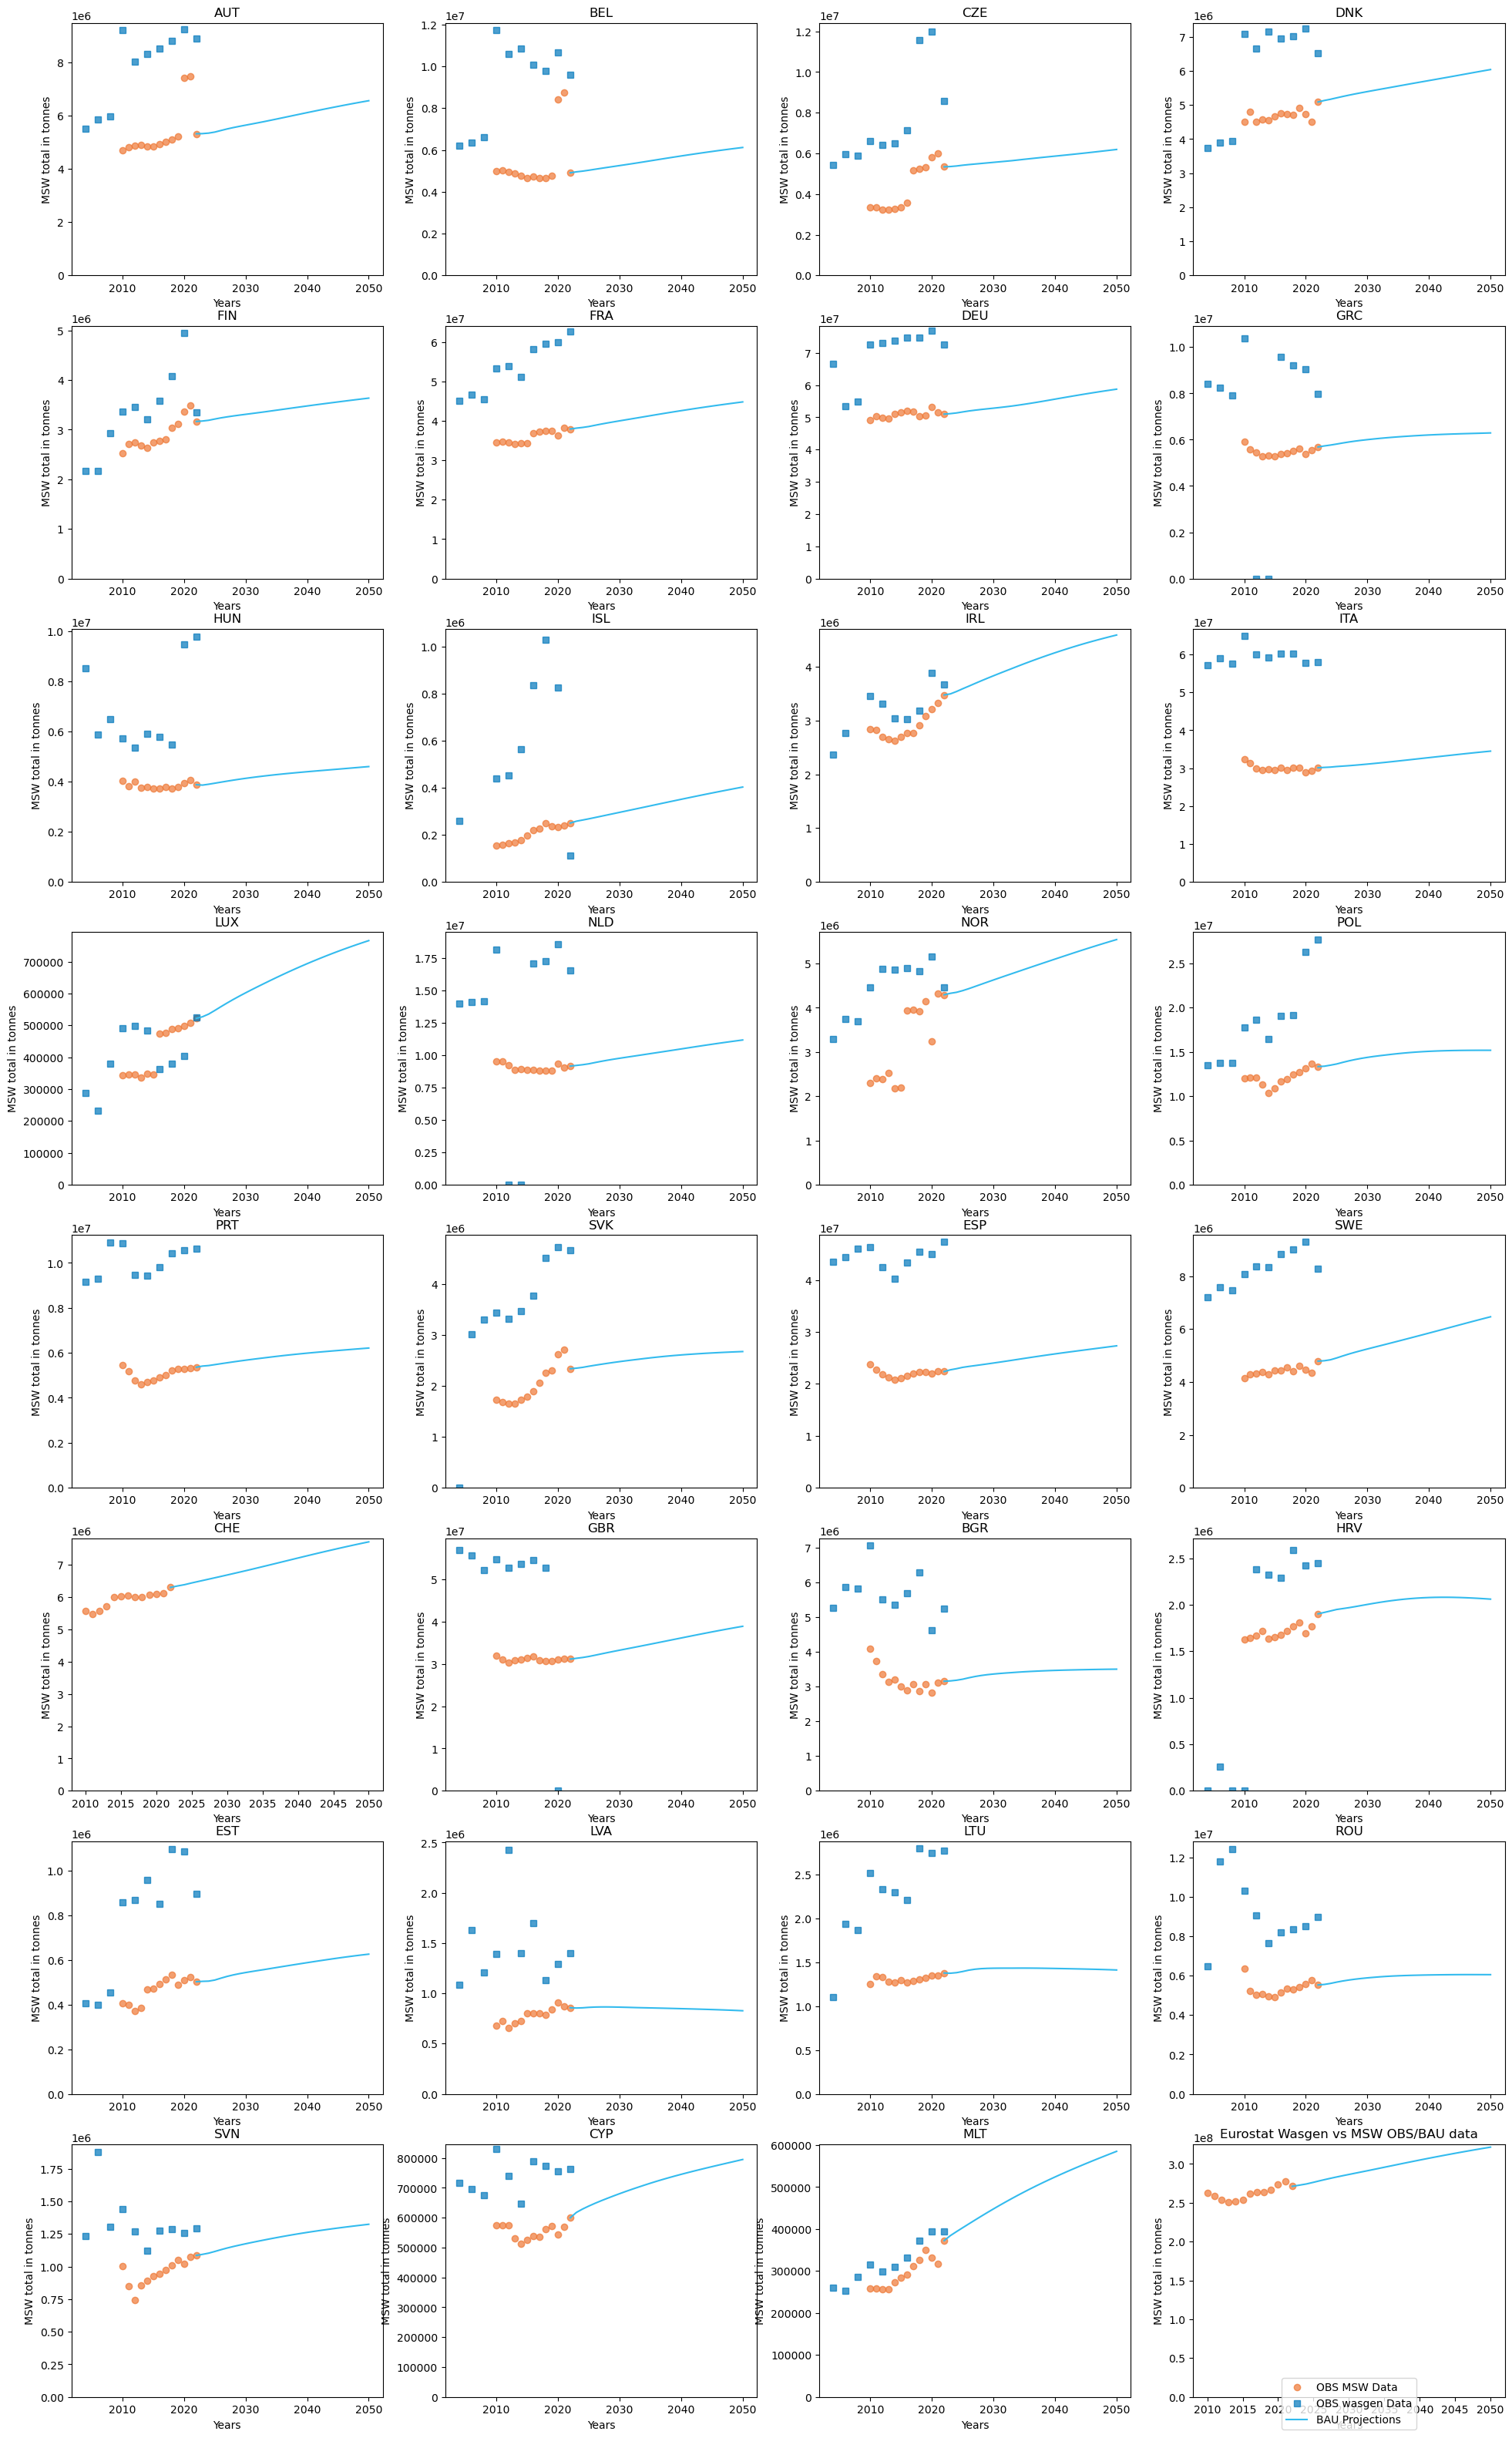

In [58]:
figure, axes = plt.subplots(8,4, figsize=(24, 40))
axes=axes.flatten()
i = 0
for country in msw_data_total_plot['LOCATION'].unique():
    reg_data_1 = msw_data_total_plot.loc[msw_data_total_plot['LOCATION'] == country]
    reg_data_2 = msw_wf_comp_total.loc[msw_wf_comp_total['NUTS_code'] == country]
    axes[i].plot()
    
    axes[i].plot(reg_data_1.loc[reg_data_1['TIME'] <= 2022]['TIME'],
                reg_data_1.loc[reg_data_1['TIME'] <= 2022]['MSW_GEN_T'],
                'o', label='OBS MSW Data', color='#EE7733', alpha = 0.7)

    axes[i].plot(reg_data_2.loc[reg_data_2['TIME_PERIOD'] <= 2022]['TIME_PERIOD'],
                reg_data_2.loc[reg_data_2['TIME_PERIOD'] <= 2022]['MSW Total'],
                's', label='OBS wasgen Data', color='#0077BB', alpha=0.7)

    x = np.arange(2022, 2051)
    axes[i].plot(x, reg_data_1['MSW_GEN_T'].loc[reg_data_1['TIME'].isin(x)],
                '-', label='BAU Projections', color= '#33BBEE')
    axes[i].set_ylim(0)
    axes[i].set_xlabel('Years')
    axes[i].set_ylabel('MSW total in tonnes')
    axes[i].set_title(country)
    i=i+1

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15))
plt.title('Eurostat Wasgen vs MSW OBS/BAU data')
plt.show()

### Plot 2: Eurostat was gen totals vs MSW totals vs country_sample_total: Austria

In [67]:
msw_wf_comp_total_exmin_aut = msw_wf_comp_total_exmin.loc[msw_wf_comp_total_exmin['NUTS_code'] == 'AUT']

In [88]:
msw_aut = msw_data_total_plot.loc[msw_data_total_plot['LOCATION']=='AUT']

In [76]:
msw_sample_ref = msw_sample.loc[msw_sample['scenario']=='reference']

In [75]:
msw_sample['scenario'].unique()

array(['counterfactual', 'reference', 'policy', 'narrow', 'slow', 'close',
       'MFRappl', 'circular', 'all'], dtype=object)

In [80]:
msw_sample_ref = msw_sample_ref.groupby(['country', 'region', 'sector', 'wregion', 'year', 'urt',
       'activity'], as_index=False)['perc'].sum().reset_index()

In [82]:
msw_sample_ref = msw_sample_ref.groupby(['country', 'region', 'wregion', 'year'], as_index=False)['activity'].sum().reset_index()

In [ ]:
msw_sample_ref['activity']*=1000000

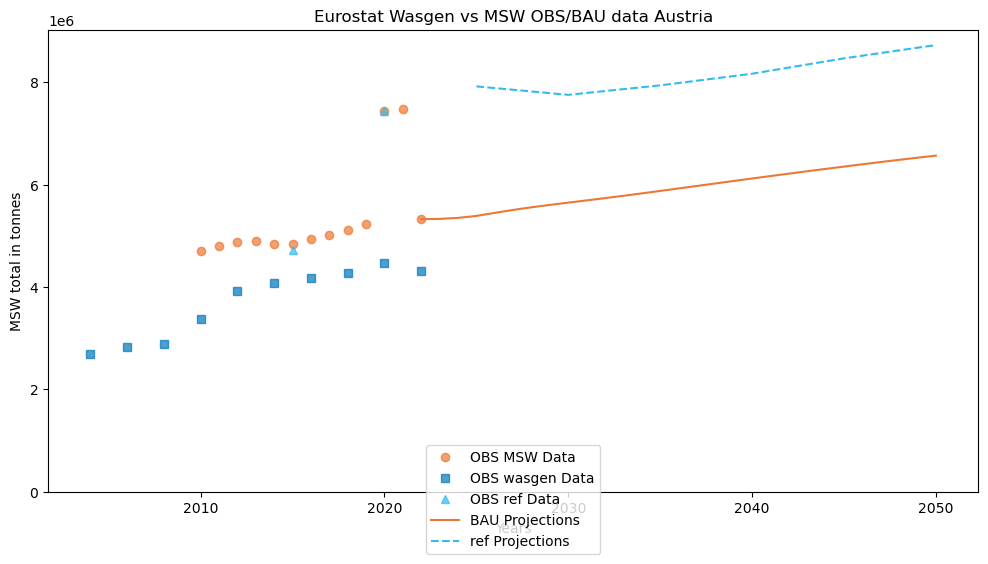

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(msw_aut.loc[msw_aut['TIME'] <= 2022]['TIME'],
    msw_aut.loc[msw_aut['TIME'] <= 2022]['MSW_GEN_T'],
    'o', label='OBS MSW Data', color='#EE7733', alpha=0.7)
ax.plot(msw_wf_comp_total_exmin_aut.loc[msw_wf_comp_total_exmin_aut['TIME_PERIOD'] <= 2022]['TIME_PERIOD'],
                msw_wf_comp_total_exmin_aut.loc[msw_wf_comp_total_exmin_aut['TIME_PERIOD'] <= 2022]['MSW Total'],
                's', label='OBS wasgen Data', color='#0077BB', alpha=0.7)
ax.plot(msw_sample_ref.loc[msw_sample_ref['year']<=2022]['year'],
         msw_sample_ref.loc[msw_sample_ref['year']<=2022]['activity'],
         '^', label='OBS ref Data', color= '#33BBEE', alpha=0.7)

x = np.arange(2022, 2051)
ax.plot(x, msw_aut['MSW_GEN_T'].loc[msw_aut['TIME'].isin(x)],
                '-', label='BAU Projections',color='#EE7733')
ax.plot(msw_sample_ref.loc[msw_sample_ref['year']>2022]['year'], msw_sample_ref.loc[msw_sample_ref['year']>2022]['activity'],
                '--', label='ref Projections',color='#33BBEE')

ax.set_ylim(0)
ax.set_xlabel('Years')
ax.set_ylabel('MSW total in tonnes')
ax.set_title(country)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15))
plt.title('Eurostat Wasgen vs MSW OBS/BAU data Austria')
plt.show()


## Waste Fraction composition

### Plot 3: Eurostat wasgen composition timeseries trends (percent) per country 

In [1]:
msw_wf_comp.head()

NameError: name 'msw_wf_comp' is not defined

### Plot 4: Eurostat wasgen composition fractions times series vs country_sample: Austria

## Waste treatment of waste fractions country_sample

### Plot 5: Treatment trend (RCY vs INC vs Landfill) of total 

### Table 3: Category matching: Eurostat, elemental data 